## Import Libraries

Import `numpy`, `cv2`, `tensorflow.keras.datasets.mnist`, and `matplotlib.pyplot`.


In [ ]:
import numpy as np
import cv2
import tensorflow.keras.datasets.mnist
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## Load MNIST Dataset

Load the MNIST dataset using `tf.keras.datasets.mnist.load_data()`.


In [ ]:
mnist = tensorflow.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")
print("MNIST dataset loaded successfully.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)
MNIST dataset loaded successfully.


## Select and Display an Element

Select one image and its corresponding label from the loaded MNIST dataset and display it using `CV2`.


<class 'numpy.uint8'>
(28, 28)


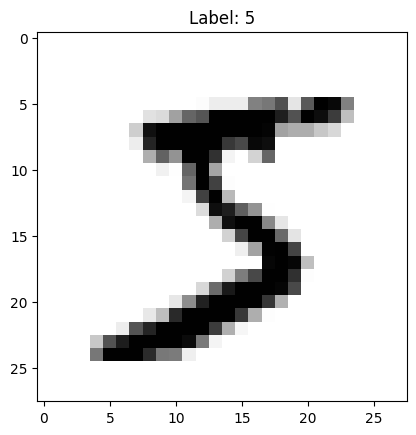

In [ ]:
index = 0
image = x_train[index]
label = y_train[index]
print(type(image[0][0]))
print(image.shape)

plt.imshow(image, cmap=plt.cm.binary)
plt.title(f"Label: {label}")
plt.show()

## Preprocess Data for LeNet-5

Reshape the MNIST images to include a channel dimension (28, 28, 1) and normalize the pixel values to the range [0, 1]. Convert labels to one-hot encoded format.


In [ ]:
import tensorflow as tf

# 1. Reshape images to include a channel dimension
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# 2. Normalize pixel values to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Convert labels to one-hot encoded format
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

print(f"x_train shape after reshape and normalization: {x_train.shape}, dtype: {x_train.dtype}")
print(f"y_train shape after one-hot encoding: {y_train.shape}, dtype: {y_train.dtype}")
print(f"x_test shape after reshape and normalization: {x_test.shape}, dtype: {x_test.dtype}")
print(f"y_test shape after one-hot encoding: {y_test.shape}, dtype: {y_test.dtype}")
print("Data preprocessing completed successfully.")

x_train shape after reshape and normalization: (60000, 28, 28, 1), dtype: float32
y_train shape after one-hot encoding: (60000, 10), dtype: float64
x_test shape after reshape and normalization: (10000, 28, 28, 1), dtype: float32
y_test shape after one-hot encoding: (10000, 10), dtype: float64
Data preprocessing completed successfully.


## Define LeNet-5 Model

Construct the LeNet-5 CNN architecture using `tf.keras.Sequential`. This will include Conv2D, Activation, MaxPooling2D, Flatten, and Dense layers as specified by LeNet-5.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D,MaxPooling2D, Flatten, Dense, Input

# Initialize a Sequential model
model = Sequential([
    Input(shape=(28, 28, 1), name='input_layer'),

    # C1: Convolutional layer
    Conv2D(filters=6, kernel_size=(5, 5), activation='relu', name='conv1'),

    # S2: Pooling layer
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='pool1'),

    # C3: Convolutional layer
    Conv2D(filters=16, kernel_size=(5, 5), activation='relu', name='conv2'),

    # S4: Pooling layer
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='pool2'),

    # Flatten the output for the fully connected layers
    Flatten(name='flatten'),

    # F5: Fully connected layer
    Dense(units=120, activation='relu', name='dense1'),

    # F6: Fully connected layer
    Dense(units=84, activation='relu', name='dense2'),

    # Output layer
    Dense(units=10, activation='softmax', name='output_layer')
], name = 'LeNet-5')

# Print the model summary
model.summary()

print("LeNet-5 model architecture defined successfully.")

Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

LeNet-5 model architecture defined successfully.


## Compile LeNet-5 Model

Compile the defined LeNet-5 model, specifying an optimizer (e.g., Adam), a loss function (e.g., `categorical_crossentropy` since labels are one-hot encoded), and metrics (e.g., accuracy).


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("LeNet-5 model compiled successfully.")

LeNet-5 model compiled successfully.


## Train LeNet-5 Model

Train the compiled LeNet-5 model using the preprocessed training data (`x_train`, `y_train`). Specify the number of epochs and batch size.


In [ ]:
history = model.fit(x_train, y_train, epochs= 8, batch_size=32, validation_split=0.1)

print("LeNet-5 model training completed successfully.")

Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.8737 - loss: 0.4108 - val_accuracy: 0.9812 - val_loss: 0.0611
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9798 - loss: 0.0654 - val_accuracy: 0.9857 - val_loss: 0.0472
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9841 - loss: 0.0473 - val_accuracy: 0.9878 - val_loss: 0.0438
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9885 - loss: 0.0377 - val_accuracy: 0.9877 - val_loss: 0.0473
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9909 - loss: 0.0289 - val_accuracy: 0.9892 - val_loss: 0.0419
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9917 - loss: 0.0241 - val_accuracy: 0.9878 - val_loss: 0.0469
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9935 - loss: 0.0215 - val_accuracy: 0.9898 - val_loss: 0.0375
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9940 - loss: 0

#Evaluation of the Model

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0351
Test Accuracy: 0.9909


# Saving the Model

## Inspect Model Layer Data Types and Shapes

Generate code to iterate through the model's layers and print their names, input shapes, and output shapes, providing insight into the type of data each layer processes.



Layer Name: conv1
  Input Shape: (None, 28, 28, 1)
  Output Shape: (None, 24, 24, 6)
  Number of Weights: 156
  Kernel Weights Shape: (5, 5, 1, 6)
  Kernel Weights (<class 'numpy.ndarray'>):
  Kernel Weights Type (<class 'numpy.float32'>):


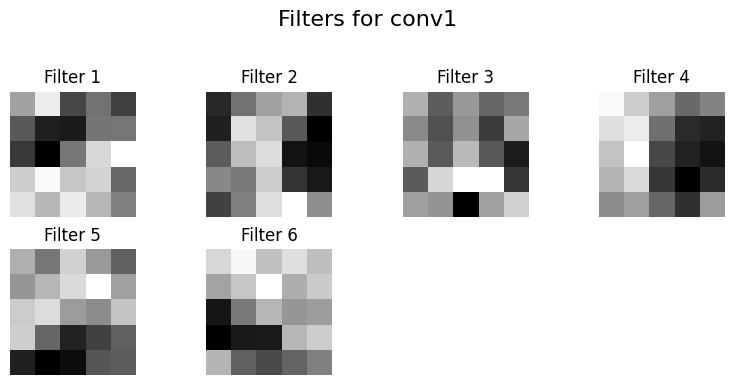


Layer Name: pool1
  Input Shape: (None, 24, 24, 6)
  Output Shape: (None, 12, 12, 6)
  Number of Weights: 0
  No weights found for this Conv2D layer.

Layer Name: conv2
  Input Shape: (None, 12, 12, 6)
  Output Shape: (None, 8, 8, 16)
  Number of Weights: 2416
  Kernel Weights Shape: (5, 5, 6, 16)
  Kernel Weights (<class 'numpy.ndarray'>):
  Kernel Weights Type (<class 'numpy.float32'>):


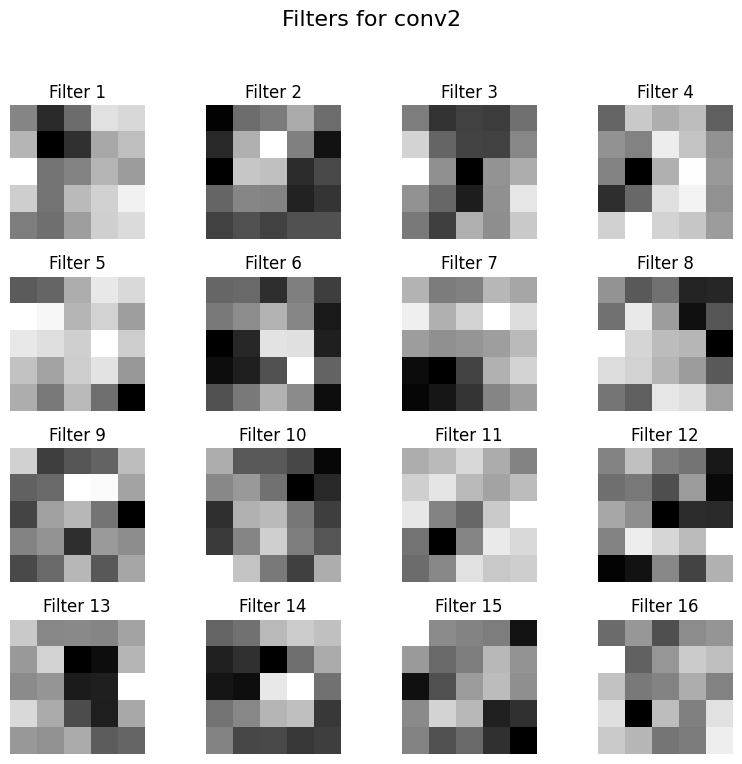


Layer Name: pool2
  Input Shape: (None, 8, 8, 16)
  Output Shape: (None, 4, 4, 16)
  Number of Weights: 0
  No weights found for this Conv2D layer.

Layer Name: flatten
  Input Shape: (None, 4, 4, 16)
  Output Shape: (None, 256)
  Number of Weights: 0
  No weights found for this Conv2D layer.

Layer Name: dense1
  Input Shape: (None, 256)
  Output Shape: (None, 120)
  Number of Weights: 30840
  Kernel Weights Shape: (256, 120)
  Kernel Weights (<class 'numpy.ndarray'>):
  Kernel Weights Type (<class 'numpy.float32'>):

Layer Name: dense2
  Input Shape: (None, 120)
  Output Shape: (None, 84)
  Number of Weights: 10164
  Kernel Weights Shape: (120, 84)
  Kernel Weights (<class 'numpy.ndarray'>):
  Kernel Weights Type (<class 'numpy.float32'>):

Layer Name: output_layer
  Input Shape: (None, 84)
  Output Shape: (None, 10)
  Number of Weights: 850
  Kernel Weights Shape: (84, 10)
  Kernel Weights (<class 'numpy.ndarray'>):
  Kernel Weights Type (<class 'numpy.float32'>):


In [ ]:
# Iterate through each layer in the model
for i, layer in enumerate(model.layers):
    # Retrieve weights (kernel and bias). Kernel weights are usually the first element.
    print(f"\nLayer Name: {layer.name}")
    print(f"  Input Shape: {layer.input.shape}")
    print(f"  Output Shape: {layer.output.shape}")
    # print(f"  Layer Output Tensor: {layer}") # Added this line
    print(f"  Number of Weights: {layer.count_params()}")
    weights = layer.get_weights()
    if len(weights) > 0:
        kernel_weights = weights[0]
        print(f"  Kernel Weights Shape: {kernel_weights.shape}")
        print(f"  Kernel Weights ({type(kernel_weights)}):")
        # print(kernel_weights) # This will print the raw NumPy array values
        if isinstance(layer, tf.keras.layers.Conv2D):
            print(f"  Kernel Weights Type ({type(kernel_weights[0][0][0][0])}):")
            num_filters = kernel_weights.shape[-1]
            # Determine grid size for plotting (e.g., square or rectangular arrangement)
            # Max 8 filters per row for better readability
            cols = min(num_filters, 4)
            rows = int(np.ceil(num_filters / cols))

            plt.figure(figsize=(cols * 2, rows * 2))
            plt.suptitle(f"Filters for {layer.name}", fontsize=16)

            for filter_idx in range(num_filters):
                plt.subplot(rows, cols, filter_idx + 1)
                # Extract one filter. It might have multiple channels depending on the input
                # For first layer (conv1), input channel is 1, so kernel_weights[:, :, 0, filter_idx]
                # For subsequent layers (conv2), input channels are > 1, so we take the sum or average
                # across input channels, or just one channel for simplicity.
                if kernel_weights.shape[2] == 1: # First Conv2D layer
                    # Take the single channel for visualization
                    filter_image = kernel_weights[:, :, 0, filter_idx]
                else:
                    # For layers with multiple input channels, sum across them or take the first channel
                    # Summing for a single grayscale representation is a common approach
                    filter_image = np.sum(kernel_weights[:, :, :, filter_idx], axis=-1)

                # Normalize filter values to 0-255 for proper grayscale display
                # cv2.normalize requires a source, destination, alpha, beta, and normalization type
                normalized_filter = cv2.normalize(
                    filter_image,
                    None,
                    alpha=0,
                    beta=255,
                    norm_type=cv2.NORM_MINMAX,
                    dtype=cv2.CV_8U
                )

                plt.imshow(normalized_filter, cmap='gray')
                plt.title(f"Filter {filter_idx + 1}")
                plt.axis('off')
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
            plt.show()
        else:
            print(f"  Kernel Weights Type ({type(kernel_weights[0][0])}):")
    else:
        print("  No weights found for this Conv2D layer.")

## Save the Model
Generate code to save the trained Keras model to a file. I will use the new Keras v3 format (.keras) by default, and also explain other common formats like HDF5 (.h5) and SavedModel format.


In [ ]:
import os
from google.colab import drive
import numpy as np # Import numpy for saving data
import matplotlib.pyplot as plt # Import matplotlib for saving PNG images

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the path to save the model and data in Google Drive
model_save_dir = '/content/drive/My Drive/LeNet-5'
os.makedirs(model_save_dir, exist_ok=True)
model_save_path = os.path.join(model_save_dir, 'Model/lenet5_mnist_model.keras')

# Save the model
model.save(model_save_path)
print(f"LeNet-5 model saved successfully to '{model_save_path}' (Keras v3 format).")

# Save the training and test data in .npy format
# np.save(os.path.join(model_save_dir, 'x_train.npy'), x_train)
# np.save(os.path.join(model_save_dir, 'y_train.npy'), y_train)
# np.save(os.path.join(model_save_dir, 'x_test.npy'), x_test)
# np.save(os.path.join(model_save_dir, 'y_test.npy'), y_test)
# print("Training and test data (x_train, y_train, x_test, y_test) saved successfully as .npy files.")

# # Save the training and test data in .csv format
# # Flatten image data for CSV storage
# x_train_flat = x_train.reshape(x_train.shape[0], -1)
# x_test_flat = x_test.reshape(x_test.shape[0], -1)

# np.savetxt(os.path.join(model_save_dir, 'x_train.csv'), x_train_flat, delimiter=',')
# np.savetxt(os.path.join(model_save_dir, 'y_train.csv'), y_train, delimiter=',')
# np.savetxt(os.path.join(model_save_dir, 'x_test.csv'), x_test_flat, delimiter=',')
# np.savetxt(os.path.join(model_save_dir, 'y_test.csv'), y_test, delimiter=',')
# print("Training and test data (x_train, y_train, x_test, y_test) saved successfully as .csv files.")

# Save a sample of training and test images in .png format
sample_images_dir = os.path.join(model_save_dir, 'Corpus/sample_images')
os.makedirs(sample_images_dir, exist_ok=True)

num_samples_to_save = 5 # Save 5 sample images from each set

for i in range(num_samples_to_save):
    # Denormalize and convert to uint8 for image saving
    img_train = (x_train[i] * 255).astype(np.uint8).squeeze()
    plt.imsave(os.path.join(sample_images_dir, f'x_train_sample_{i}.png'), img_train, cmap='gray')

    img_test = (x_test[i] * 255).astype(np.uint8).squeeze()
    plt.imsave(os.path.join(sample_images_dir, f'x_test_sample_{i}.png'), img_test, cmap='gray')

print(f"A sample of {num_samples_to_save} training and test images saved successfully as .png files in '{sample_images_dir}'.")

Mounted at /content/drive
LeNet-5 model saved successfully to '/content/drive/My Drive/saved_models/lenet5_mnist_model.keras' (Keras v3 format).
Training and test data (x_train, y_train, x_test, y_test) saved successfully as .npy files.
Training and test data (x_train, y_train, x_test, y_test) saved successfully as .csv files.
A sample of 5 training and test images saved successfully as .png files in '/content/drive/My Drive/saved_models/sample_images'.
